# Treatment geometries, budget, and the settlement

**CITS4403 Computational Modelling · notebook 02 of 03**

Notebook 01 established that the model is correct. This one is the project's contribution: with a **fixed** prescribed-burning budget, does it matter *how* the burns are arranged on the landscape?

Every figure here comes from the registry in `figures/make_figures.py`, which reads `results/` and never runs the simulator. The one exception is the gallery in part 1, which calls the geometry generators directly to draw what each arrangement looks like; that is not a simulation. Every number quoted in prose is computed in a visible cell.

1. [What the arrangements look like](#1.-What-the-arrangements-look-like)
2. [The clustering-scale axis](#2.-The-clustering-scale-axis)
3. [Efficiency: burned area avoided per unit treated](#3.-Efficiency)
4. [The settlement trade-off (SQ4)](#4.-The-settlement-trade-off)
5. [What the fires actually look like](#5.-What-the-fires-actually-look-like)

**Prerequisites:** `python run.py --exp 1` and `--exp scars`.

In [1]:
%matplotlib inline
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from figures.make_figures import CAPTIONS, FIGURES, STYLE
from src import geometries          # the gallery only; no simulation in this notebook

exp1 = pd.read_parquet(ROOT / "results" / "exp1.parquet")
print(f"Experiment 1: {len(exp1):,} runs, {exp1['run_id'].nunique():,} distinct configurations")
print(f"figures available: {', '.join(FIGURES)}")

Experiment 1: 107,200 runs, 107,200 distinct configurations
figures available: validation, exp1-coarse, clustering-scale, efficiency, threshold-shift, burn-size-distributions, sq4-tradeoff, wind-interaction, sensitivity, scars, scars-space-time


## 1. What the arrangements look like

Each arrangement spends the **same** budget: 15% of the fuel cells are prescribed-burned, which drops their fuel load from 1 to 0.2. What differs is only where those cells sit.

The clustering scale (project-context.md §11) is the linear size of a contiguous treated region: 1 for `random`, `k` for `patches(k)`, `w` for `strips(w)`. That single number is the axis the main analysis is built on. `buffer` is the targeted condition and deliberately sits off that axis.

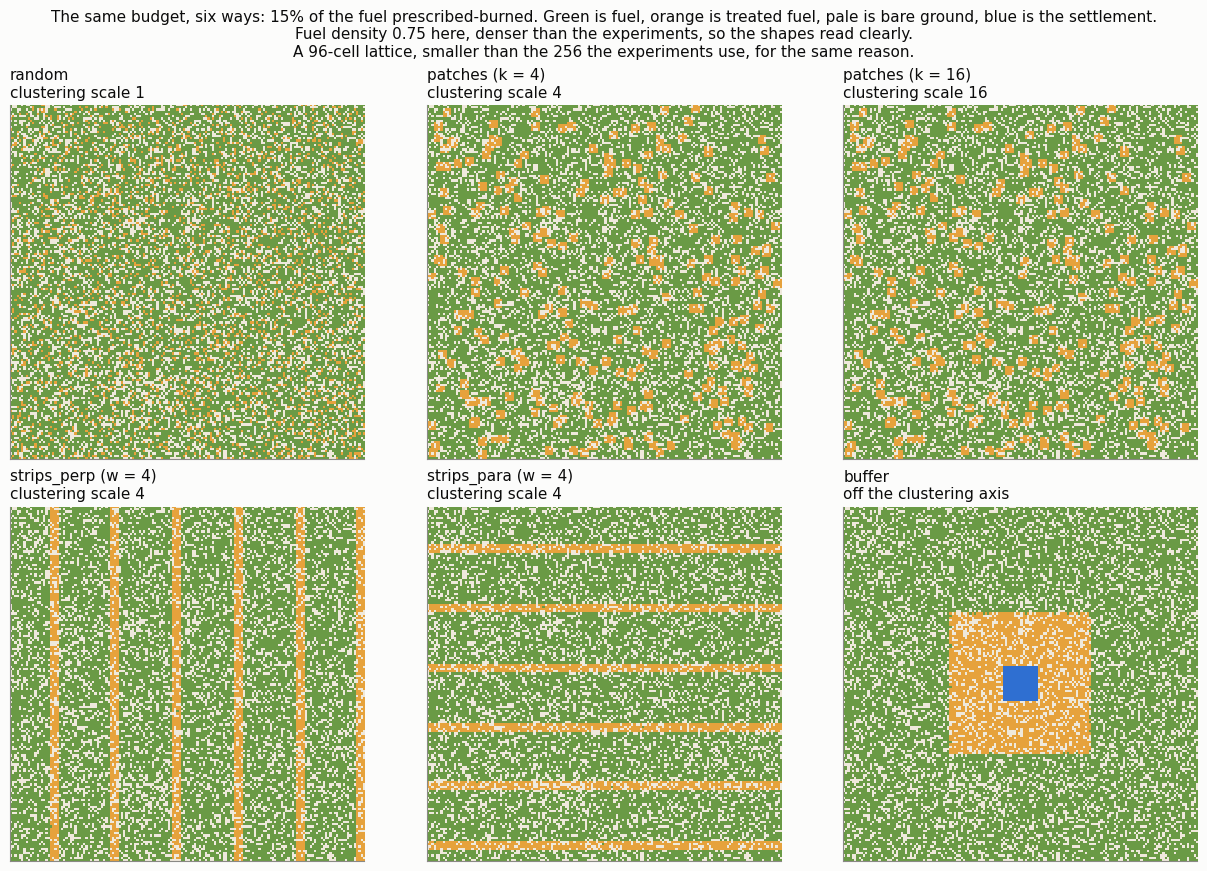

In [2]:
# The generators are pure functions of (rng, occupancy, budget), so the gallery
# draws real masks without simulating anything.
# A denser fuel bed than the experiments use (0.75 against roughly 0.5), purely so
# the block and strip shapes read clearly: treatment only marks fuel cells, so at
# experiment densities a 16x16 block looks like a dotted square rather than a solid one.
L, P, B, SEED = 160, 0.75, 0.15, 7
rng = np.random.default_rng(SEED)
occupied = rng.random((L, L)) < P
n_treat = round(B * occupied.sum())
side = 16
centre = slice(L // 2 - side // 2, L // 2 - side // 2 + side)

gallery = [("random", {}), ("patches", {"k": 4}), ("patches", {"k": 16}),
           ("strips_perp", {"w": 4}), ("strips_para", {"w": 4}), ("buffer", {})]

with plt.rc_context(STYLE):
    fig, axes = plt.subplots(2, 3, figsize=(12.5, 8.6), layout="constrained")
    for ax, (condition, params) in zip(axes.ravel(), gallery):
        field = occupied.copy()
        if condition == "buffer":
            field[centre, centre] = False          # the settlement is not fuel
        mask = geometries.generate(condition, np.random.default_rng(SEED), field,
                                   round(B * field.sum()), phi=0.0, settlement_side=side)
        img = np.where(field, 1, 0)
        img[mask] = 2
        if condition == "buffer":
            img[centre, centre] = 3
        ax.imshow(img, cmap=plt.matplotlib.colors.ListedColormap(
            ["#efe9dc", "#6a9a45", "#e6a23c", "#2f6fd1"]), vmin=0, vmax=3, interpolation="nearest")
        scale = {"random": 1}.get(condition, list(params.values())[0] if params else None)
        ax.set_title(f"{condition}" + (f" ({list(params)[0]} = {list(params.values())[0]})" if params else "")
                     + (f"\nclustering scale {scale}" if scale else "\noff the clustering axis"))
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.suptitle(f"The same budget, six ways: {B:.0%} of the fuel prescribed-burned. Green is fuel, "
                 f"orange is treated fuel, pale is bare ground, blue is the settlement.\n"
                 f"Fuel density {P} here, denser than the experiments, so the shapes read clearly.\nA 96-cell lattice, smaller than the 256 the experiments use, for the same reason.",
                 fontsize=11)
plt.show()

Reading across the gallery: `random` scatters single cells, so it breaks up the fuel everywhere but leaves no continuous break. `patches` concentrates the same budget into blocks, which leaves wide corridors of untouched fuel between them. The strips spend it on a few long continuous breaks, and the only difference between the two strip conditions is whether those breaks run across the wind or along it. `buffer` spends the whole budget ringing the settlement and leaves the rest of the landscape untreated.

The question is which of these buys the most protection.

## 2. The clustering-scale axis

Experiment 1 ran every arrangement across seven budgets, four fuel densities and two wind strengths, 200 fires each: 107,200 fires in total. Each fire starts from a single random fuel cell on a 256 × 256 landscape with a settlement in the middle.

The figure below puts burned area against clustering scale, so `random`, `patches` and `strips` sit on one continuous axis rather than in separate groups.

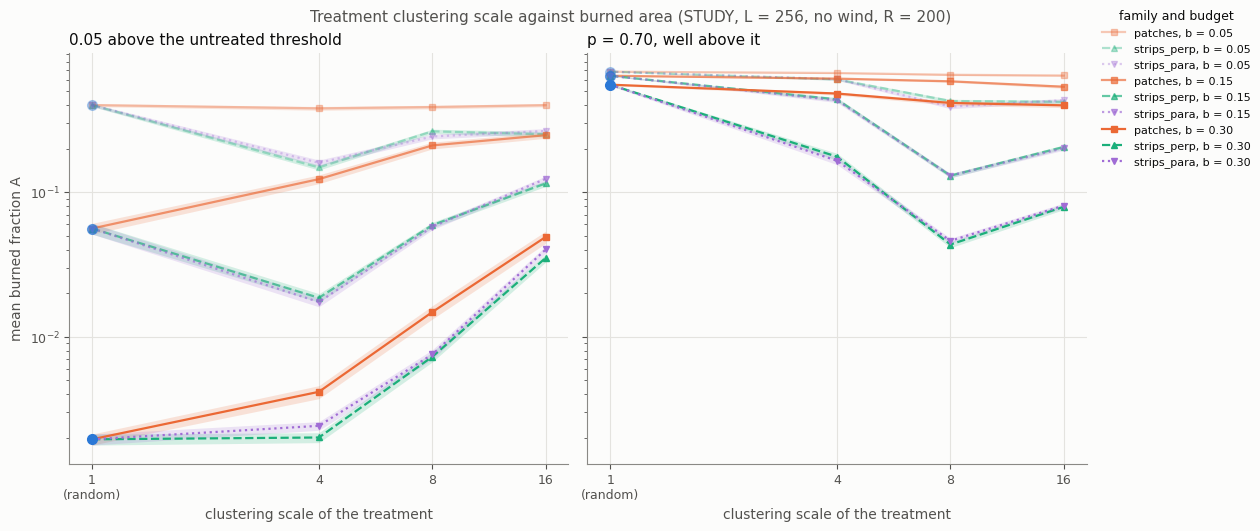

In [3]:
fig = FIGURES["clustering-scale"]()
fig

In [4]:
display(Markdown("**Caption.** " + CAPTIONS["clustering-scale"]))

**Caption.** Mean burned fraction A against the clustering scale of the treatment, the continuous axis of the primary analysis (project-context.md §11): scale 1 is `random`, scale k is `patches(k)`, scale w is `strips(w)`. Fires start at one random fuel cell on a 256x256 lattice with a settlement; each point is 200 replicates. Panels are fuel density: 0.05 above the untreated threshold (left) and the absolute p = 0.70 well above it (right), both with no wind. Line style separates the three families that share the axis; `buffer` is the targeted condition and sits off this axis, so it is not shown. Bands are +/- 1 standard error of the mean. Budgets are the realised treated fraction of the fuel.

In [5]:
# the numbers the next paragraph quotes
head = exp1[(exp1.kappa == 0) & np.isclose(exp1.p_rel.fillna(np.inf), 0.05)]
head = head[np.isclose(head.b, 0.15) | (head.condition == "none")]
head = head.assign(level=[c if c in ("none", "random", "buffer") else
                          f"{c} {'k' if c == 'patches' else 'w'}="
                          f"{json.loads(g).get('k', json.loads(g).get('w'))}"
                          for c, g in zip(head.condition, head.geometry_params)])
summary = head.groupby("level").agg(
    burned_fraction=("burned_fraction", "mean"),
    reached_settlement=("settlement_reached", "mean"),
    realised_budget=("n_treated", lambda s: (s / head.loc[s.index, "n_occupied"]).mean()),
).sort_values("burned_fraction").round(4)
summary

,burned_fraction,reached_settlement,realised_budget
level,,,
strips_para w=4,0.0174,0.035,0.15
strips_perp w=4,0.0186,0.075,0.15
random,0.0561,0.265,0.15
strips_para w=8,0.0576,0.175,0.15
strips_perp w=8,0.0592,0.165,0.15
strips_perp w=16,0.1150,0.3,0.15
patches k=4,0.1231,0.46,0.15
strips_para w=16,0.1239,0.34,0.15
patches k=8,0.2105,0.64,0.15


**The two regimes point in opposite directions, and that is the main finding of this figure.**

Just above the untreated threshold (left panel), burned area *rises* with clustering scale for every budget: scattering the treatment is better than concentrating it. At a 15% budget the untreated landscape burns 44% of itself, `random` brings that down to 5.6%, and `patches(16)` only to 24.8% — the same budget, four times the damage, purely because it was clumped.

Well above the threshold (right panel), the ordering reverses in the middle of the axis: the strips become far more effective than anything scattered, with a minimum around a width of 8. There the landscape is so well connected that scattered treatment cannot break it up at all, and only a continuous barrier helps.

So there is no single best clustering scale. It depends on how much fuel the landscape is carrying relative to its own critical point, which is exactly why the next notebook measures where that critical point moves to.

## 3. Efficiency

Burned area alone rewards spending more. The efficiency metric (project-context.md §11) divides the avoided burned area by the area actually treated:

$$\text{efficiency} = \frac{A_{\text{untreated}} - A_{\text{treated}}}{n_{\text{treated}} / n_{\text{cells}}}$$

It uses the **realised** treated count on every row, never the nominal budget, because the generators hit the budget in occupied cells and the realised fraction of the whole lattice is what was actually spent.

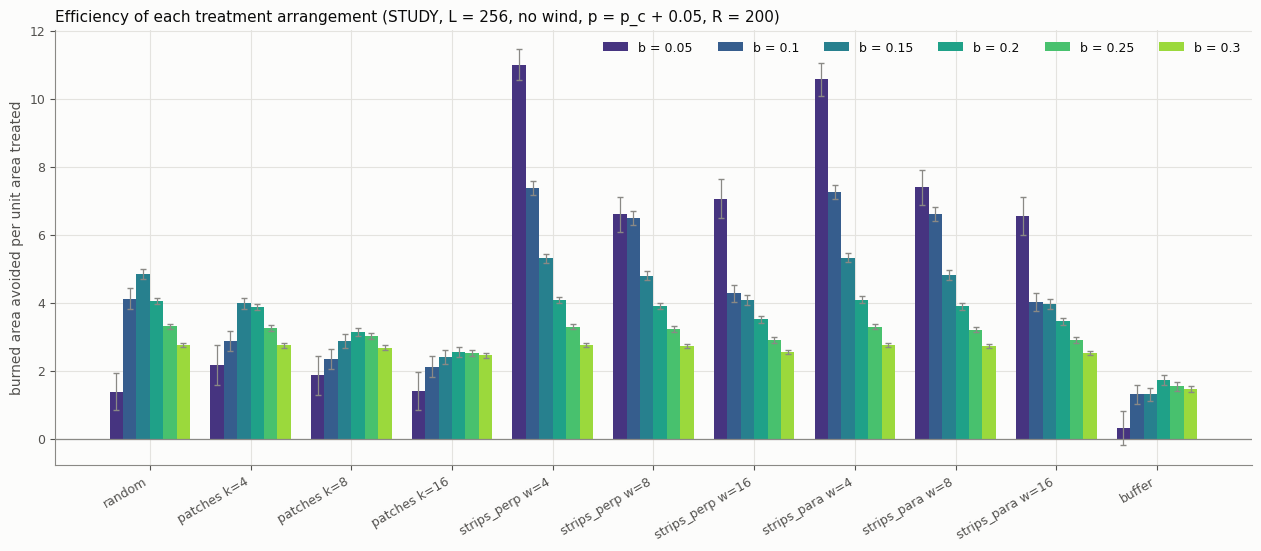

In [6]:
fig = FIGURES["efficiency"]()
fig

In [7]:
display(Markdown("**Caption.** " + CAPTIONS["efficiency"]))

**Caption.** Treatment efficiency by condition and budget: burned area avoided per unit area treated, (A[untreated] - A[condition]) / (n_treated / n_cells), using the **realised** treated count on every row, never the nominal budget (project-context.md §11). Fuel density 0.05 above the untreated threshold, no wind, L = 256, 200 replicates per cell. Higher is better. Error bars are +/- 1 standard error, propagated from the treated and untreated means. Efficiency falls with budget for every condition, which is diminishing returns (SQ2).

In [8]:
# diminishing returns, as a number: efficiency at the smallest and largest budget
eff_slice = exp1[(exp1.kappa == 0) & np.isclose(exp1.p_rel.fillna(np.inf), 0.05)]
base = eff_slice[eff_slice.condition == "none"]["burned_fraction"].mean()
rows = []
for b in sorted(x for x in eff_slice.b.unique() if x > 0):
    cell = eff_slice[np.isclose(eff_slice.b, b) & (eff_slice.condition == "strips_perp")]
    cell = cell[cell.geometry_params.str.contains('"w":4')]
    treated_area = (cell.n_treated / cell.n_cells).mean()
    rows.append({"budget b": b,
                 "burned fraction": round(cell.burned_fraction.mean(), 4),
                 "efficiency": round((base - cell.burned_fraction.mean()) / treated_area, 2)})
pd.DataFrame(rows).set_index("budget b")

,burned fraction,efficiency
budget b,,
0.05,0.1482,11.00
0.10,0.0505,7.36
0.15,0.0186,5.31
0.20,0.0083,4.08
0.25,0.0041,3.30
0.30,0.0020,2.76


**Effectiveness scales with budget, but efficiency does not (SQ2).** For `strips_perp(4)`, going from a 5% to a 30% budget cuts burned area roughly tenfold, so more treatment always helps. But the efficiency column falls steadily: the first 5% of the landscape treated avoids about eleven times its own area in burning, while the last increments avoid under three times. The returns diminish sharply, which matters for a policy question where the budget is the binding constraint.

The ordering between arrangements is the same story as before: at this operating point the strips and `random` are several times more efficient than `patches`, and `buffer` is the least efficient of all — unsurprisingly, since it spends the entire budget protecting one small block rather than the landscape.

## 4. The settlement trade-off

Sub-question 4 asks whether the arrangement that minimises burned area is also the one that best protects a settlement. The settlement is a block of non-fuel cells in the middle of the landscape, and a fire "reaches" it if any cell in the one-cell ring around it catches fire.

If the answer were yes, every point below would lie on a single rising line and there would be nothing to choose. It is not.

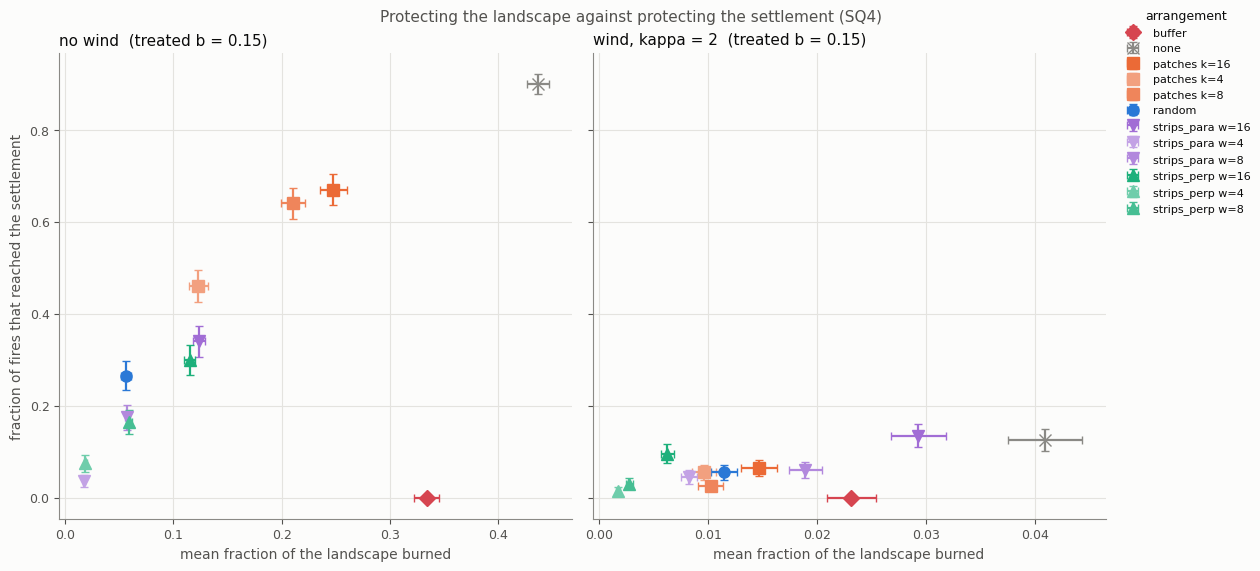

In [9]:
fig = FIGURES["sq4-tradeoff"]()
fig

In [10]:
display(Markdown("**Caption.** " + CAPTIONS["sq4-tradeoff"]))

**Caption.** The asset-against-landscape trade-off (SQ4). Each point is one treatment arrangement at the realised budget shown, placed by the mean fraction of the landscape burned (x) and the fraction of fires that reached the settlement ring (y). Fuel density 0.05 above the untreated threshold, L = 256, 200 replicates; panels are no wind and strong wind. Bars are +/- 1 standard error. The bottom-left corner is best on both measures. `buffer` sits bottom-right: it protects the settlement completely while leaving much more of the landscape burnt than the strip arrangements, so the arrangement that best protects the asset is not the one that best protects the landscape.

In [11]:
reach = summary[["burned_fraction", "reached_settlement"]].copy()
reach["burned rank"] = reach["burned_fraction"].rank().astype(int)
reach["settlement rank"] = reach["reached_settlement"].rank(method="min").astype(int)
reach.sort_values("burned_fraction")

,burned_fraction,reached_settlement,burned rank,settlement rank
level,,,,
strips_para w=4,0.0174,0.035,1,2
strips_perp w=4,0.0186,0.075,2,3
random,0.0561,0.265,3,6
strips_para w=8,0.0576,0.175,4,5
strips_perp w=8,0.0592,0.165,5,4
strips_perp w=16,0.1150,0.3,6,7
patches k=4,0.1231,0.46,7,9
strips_para w=16,0.1239,0.34,8,8
patches k=8,0.2105,0.64,9,10


**The trade-off is real, and `buffer` is where it shows.** `buffer` is the *only* arrangement that stops the fire reaching the settlement entirely — 0 of 200 fires — yet it leaves 33% of the landscape burnt, worse than every other treated arrangement and not far off the 44% of doing nothing at all. It spends the whole budget on a ring that the fire simply burns around.

For every other arrangement the two measures move together: what protects the landscape also tends to protect the settlement, because a fire that stays small is unlikely to reach anything. So the honest answer to SQ4 is a qualified yes-and-no. Among landscape-scale treatments the ranking is broadly shared, but the targeted treatment sits completely off that line, and a manager who cares only about the asset would choose an arrangement that a manager who cares about the landscape would reject.

In [12]:
# time-to-reach, the metric the settlement pilot switched to (DEC-037)
reached = head[head.settlement_reached.astype(bool)]
timing = pd.DataFrame({
    "fires that reached": head.groupby("level").settlement_reached.mean().round(3),
    "median step when they did": reached.groupby("level").settlement_reached_step.median(),
    "fires in that median": reached.groupby("level").size(),
}).sort_values("fires that reached")
timing

,fires that reached,median step when they did,fires in that median
level,,,
buffer,0.0,<NA>,NaN
strips_para w=4,0.035,55.0,7.0
strips_perp w=4,0.075,35.0,15.0
strips_perp w=8,0.165,77.0,33.0
strips_para w=8,0.175,84.0,35.0
random,0.265,128.0,53.0
strips_perp w=16,0.3,98.5,60.0
strips_para w=16,0.34,110.0,68.0
patches k=4,0.46,147.0,92.0


**A caution about the timing column, which is why the reach probability is reported beside it.** The median step is taken only over the fires that reached the settlement, and for the best arrangements that is a small and unrepresentative group: `strips_perp(4)` is reached by 15 of 200 fires, and those 15 reach it *fastest* (median step 35 against 113 untreated). That is not evidence that strips get the fire to the settlement sooner. It is survivorship: the only fires that get through a strip layout are the ones that happened to ignite inside the settlement's own compartment, so they start close and arrive quickly. Every fire that would have taken a long path has been stopped instead.

This right-censoring is why the pilot recorded both quantities (DEC-037). Time-to-reach is only interpretable alongside the probability of reaching at all, and neither should be quoted on its own.

## 5. What the fires actually look like

The statistics above are averages over 200 fires per cell. These are single runs, shown so the mechanism is visible rather than as evidence.

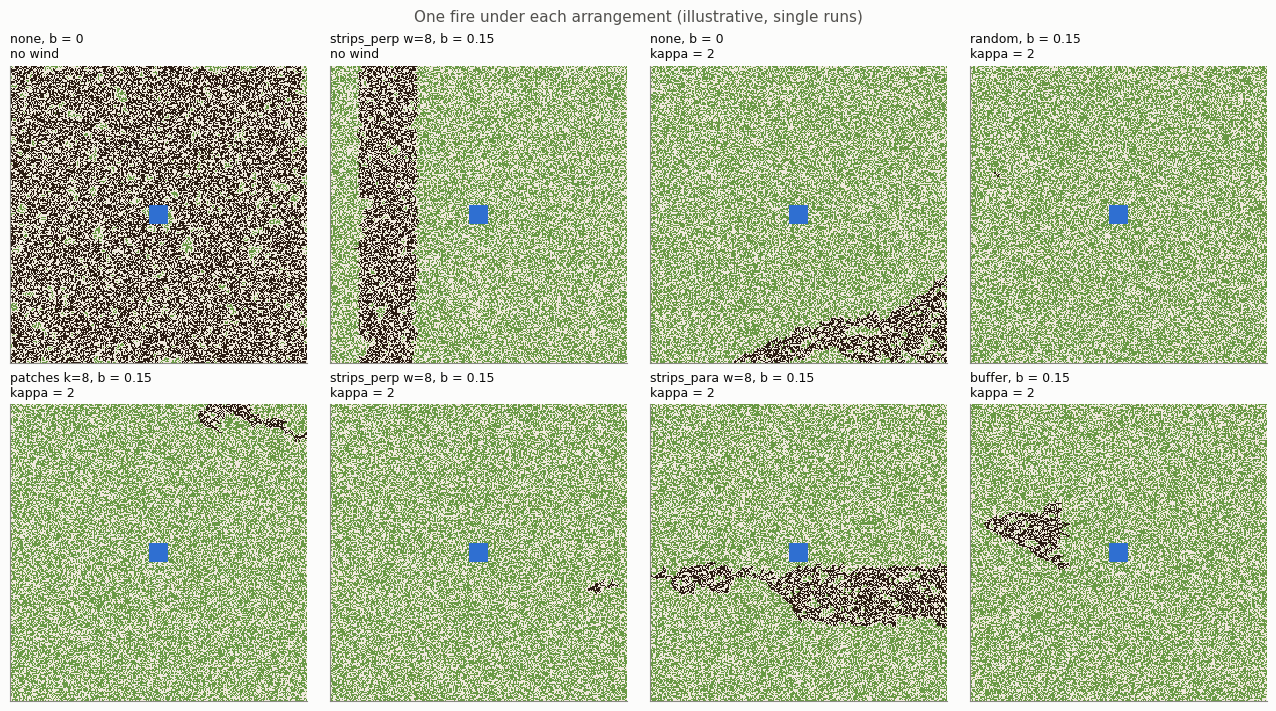

In [13]:
fig = FIGURES["scars"]()
fig

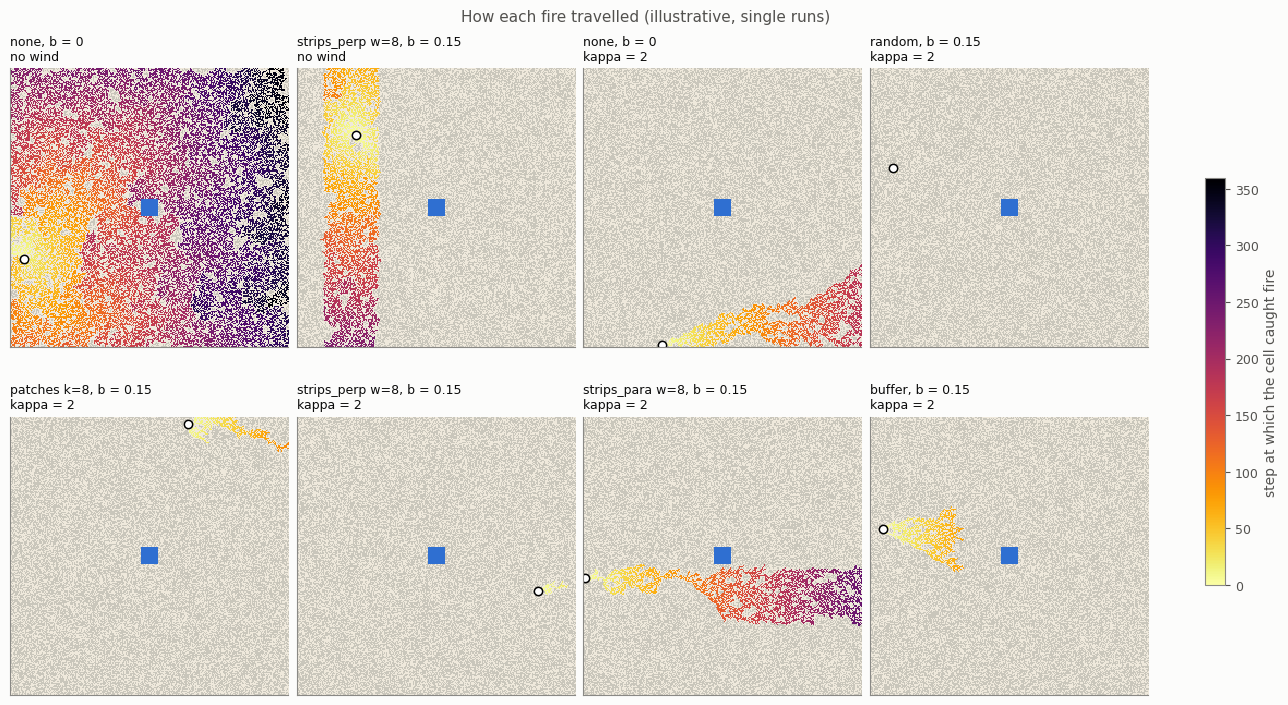

In [14]:
fig = FIGURES["scars-space-time"]()
fig

In [15]:
display(Markdown("**Caption.** " + CAPTIONS["scars-space-time"]))

**Caption.** The same illustrative fires as the scar figure, coloured by the step at which each cell caught fire, so the picture is a map of travel time from the ignition point (marked white). Pale grey is fuel that never burned. Colour spreading outward in even bands is a fire advancing freely; crowded bands are a front held up by a treated strip or a gap in the fuel. Under wind the bands stretch downwind, which is the directional kernel acting on the front rather than on the overall spread rate.

The space-time view shows the mechanism behind the numbers. In the untreated panel colour spreads smoothly outward in even bands: nothing is holding the front up, and it runs until it reaches the edge of the landscape. Under `strips_perp` the fire fills one compartment between two breaks and stops there, so the burn is a narrow band and the colour range is short — the fire ended early because it had nowhere to go, not because it burned slowly.

Under wind the bands stretch downwind into a wedge. That is the directional kernel acting on the shape of the front; the weights average to 1, so wind redirects spread rather than intensifying it.

**Next:** notebook 03 asks whether these arrangements move the critical point itself, what they do to the distribution of fire sizes, and whether any of it survives changing the model's fixed parameters.